## Load in packages and data

In [115]:
import numpy as np
import pandas as pd
# import geopandas as gpd
import matplotlib.pyplot as plt
import matsim_output_analysis_experienced_te as moa
import operator

In [1]:
df_pl = pd.read_csv(r"1405_2040_0.1pc_keep20.csv") #this is the 2040 do minimum plans
df_ex = pd.read_csv(r"1405_2040_0.1pc_keep20_experienced.csv") #this is the 2040 do minimum plans
# df_pl = pd.read_csv(r"1405_2040_10pc_keep20.csv") #this is the 2040 do minimum plans
# df_ex = pd.read_csv(r"1405_2040_10pc_keep20_experienced.csv") #this is the 2040 do minimum plans

NameError: name 'pd' is not defined

In [117]:
# THIS ONE FOR PLANNED PLANS - WON'T BE PERFECT RECREATION
# # # df_pl = pd.read_csv(r"140426_plans_te.csv") 
# # # df_ex = pd.read_csv(r"140426_experienced_plans_te.csv") 

# df_pl = df_pl[["id", "subpopulation",  'selected plan activity_type_or_mode',
#  'selected plan distance_travelled',
#  'selected plan duration',
#  'selected plan location',
#  'selected plan routes',
#  'selected plan boardingTime',
#  'selected plan number',
#  'selected plan utility',]]

# df_ex = df_ex[["id" , "selected plan activity_type_or_mode", "selected plan duration", "selected plan utility"]]
# df_ex.columns = ["id" , "experienced plan activity_type_or_mode", "experienced plan duration", "experienced plan utility"]
# df = pd.merge(df_pl, df_ex, how = "outer", on="id")

# #the following is only needed for handling experienced plans
# df["stuck_bool"] =  (df["selected plan activity_type_or_mode"] != df["experienced plan activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck

In [118]:
#THIS ONE FOR EXPERIENCED PLANS - PERFECT RECREATION
# # # df_pl = pd.read_csv(r"140426_plans_te.csv") 
# # # df_ex = pd.read_csv(r"140426_experienced_plans_te.csv") 

df_pl = df_pl[["id", "subpopulation" , "selected plan activity_type_or_mode", "selected plan duration", "selected plan utility"]]
df_pl.columns = ["id", "subpopulation" , "planned plan activity_type_or_mode", "planned plan duration", "planned plan utility"]
df = pd.merge(df_pl, df_ex, how = "outer", on="id")

#the following is only needed for handling experienced plans
df["stuck_bool"] =  (df["selected plan activity_type_or_mode"] != df["planned plan activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck

In [119]:
# df_sample = df.sample(40000)
# df_sample.to_csv("0705_domin_sample.csv")

In [120]:
# df_init = pd.read_csv("0705_domin_sample.csv")

In [121]:
df_init=df

In [122]:
df_init = df_init[~df_init["subpopulation"].isin(["hgv","lgv","airport", "lgv_ev"])] 
df_init = df_init[~df_init["id"].isin(["empty_plan"])] #choose only the actual people

In [123]:
# Rows WITH NaN in "routes" -> those with NO TRIPS 
#TODO: handle these!!
nan_rows = df_init[df_init["selected plan routes"].isna()]

# Rows WITHOUT NaN (cleaned DataFrame)
df = df_init[df_init["selected plan routes"].notna()]

In [124]:
df["stuck_bool"].unique()

array([0, 1])

In [125]:
#turn plan summaries into lists instead of long strings
df['selected plan activity_type_or_mode'] = df['selected plan activity_type_or_mode'].str.split('; ')
df['selected plan distance_travelled'] = df['selected plan distance_travelled'].str.split('; ')
df['selected plan duration'] = df['selected plan duration'].str.split('; ')
df['selected plan location'] = df['selected plan location'].str.split('; ')
df['selected plan routes'] = df['selected plan routes'].str.split('; ')
df['selected plan boardingTime'] = df['selected plan boardingTime'].str.split('; ')

<!-- ## Remove "pt interaction" terms and all corresponding columns -->

In [126]:
#extract the indices of where pt interaction happens
df['selected plan ptinteraction_indices'] = df['selected plan activity_type_or_mode'].apply(moa.get_ptinteraction_index)

In [127]:
#remove the pt interaction activities
df['selected plan activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan activity_type_or_mode']), axis=1)

In [128]:
#remove the correspinding pt interaction durations
df['selected plan duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan duration']), axis=1)

In [129]:
#remove the correspinding pt interaction locations
df['selected plan location'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan location']), axis=1)

In [130]:
#remove the correspinding pt interaction distance travelled
df['selected plan distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan distance_travelled']), axis=1)

In [131]:
#remove the correspinding pt interaction distance travelled
df['selected plan boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan boardingTime']), axis=1)

In [132]:
#remove the correspinding pt interaction distance travelled
df['selected plan routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan routes']), axis=1)

In [133]:
# #clean  up table and remove indices
# df = df.drop(["selected plan ptinteraction_indices","unselected plan (1) activity_type_or_mode", "unselected plan (1) distance_travelled", "unselected plan (1) duration", "unselected plan (1) location", "unselected plan (1) routes", "unselected plan (1) number", "unselected plan (1) utility",
#               "unselected plan (2) activity_type_or_mode", "unselected plan (2) distance_travelled", "unselected plan (2) duration", "unselected plan (2) location",  "unselected plan (2) number", "unselected plan (2) utility",
#               "unselected plan (3) activity_type_or_mode", "unselected plan (3) distance_travelled", "unselected plan (3) duration", "unselected plan (3) location",  "unselected plan (3) number", "unselected plan (3) utility",
#               "unselected plan (4) activity_type_or_mode", "unselected plan (4) distance_travelled", "unselected plan (4) duration", "unselected plan (4) location", "unselected plan (4) number", "unselected plan (4) utility"], axis=1)

## Calculating utility components

Get activity start and end times, and highlight any "stuck" agents

In [134]:
# def update_last_element(lst, stuck_bool):
#     if isinstance(lst, list) and len(lst) > 0 and stuck_bool==0:
#         lst[-1] = "24:00:00"
#     return lst

# df['selected plan duration'] =  df.apply(lambda row: update_last_element(row['selected plan duration'], row['stuck_bool']), axis=1)

In [135]:
df["legs_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["activities_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["selected plan leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["legs_indices"], row["selected plan duration"]), axis=1)
df["selected plan activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["activities_indices"], row["selected plan duration"]), axis=1)


In [136]:
df[["activity_starts", "activity_ends","stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["activities_indices"], row["selected plan duration"], row["selected plan activity_type_or_mode"], row["stuck_bool"]), axis=1, result_type="expand")

In [137]:
df["calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["activity_starts"], row["activity_ends"], row["selected plan activity_type_or_mode"], row["stuck_index"], row["stuck_bool"]), axis=1)

In [138]:
df["selected plan activities"] = df.apply(lambda row: moa.get_activities(row["selected plan activity_type_or_mode"], row["activities_indices"], row["stuck_index"]), axis=1) #this needs to account for stuckness

Now can call activity utility function as normal, BUT ADD IN PENALTY FOR NEGATIVE OVERNIGHT DURATION

In [139]:
df["calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["selected plan activity_type_or_mode"], row["activities_indices"], row["stuck_index"], row["calculated_activity_durations"], row["stuck_bool"]), axis=1)

Travel utility

In [140]:
#do the tolls
import xmltodict
import pprint

with open(r"C:\Users\maria\Documents\matsim_analysis\data\2040_dm_keep_history_0.1pc_20plans_RP\output_toll.xml\output_toll.xml", 'r', encoding='utf-8') as file:
    my_xml = file.read()
output_tolls = xmltodict.parse(my_xml)
tolls = output_tolls["roadpricing"]["links"]["link"]
tolls2  = {item['@id']: item['cost']['@amount'] for item in tolls}
# tolls2 = {} #remove this for not claudes

In [141]:
df[[ "calculated_travel_u", "tollvalue", "tollcount","transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["selected plan activity_type_or_mode"], row["selected plan duration"], row["selected plan distance_travelled"],
                            row["activities_indices"], row["subpopulation"], row["selected plan boardingTime"], 
                            row["activity_ends"], row["selected plan routes"], tolls2, row["stuck_index"]), axis=1, result_type="expand")

In [142]:
df["calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["stuck_bool"], row["stuck_index"], row["selected plan activity_type_or_mode"]), axis=1)

Sum travel, activity, and penalty to get overall score

In [143]:
df["total_travel_u"] = df.apply(lambda row: sum(row["calculated_travel_u"]), axis=1)

In [144]:
df["total_activity_u"] = df.apply(lambda row: sum(row["calculated_activity_u"]), axis=1)

In [145]:
df["calculated_total_u"] = df["total_travel_u"]+df["total_activity_u"]+df["calculated_penalty_u"]

In [146]:
df["diff"] = (df["selected plan utility"] - df["calculated_total_u"])

Text(0.5, 1.0, 'Selected plan utility score recreation (n = 4408)')

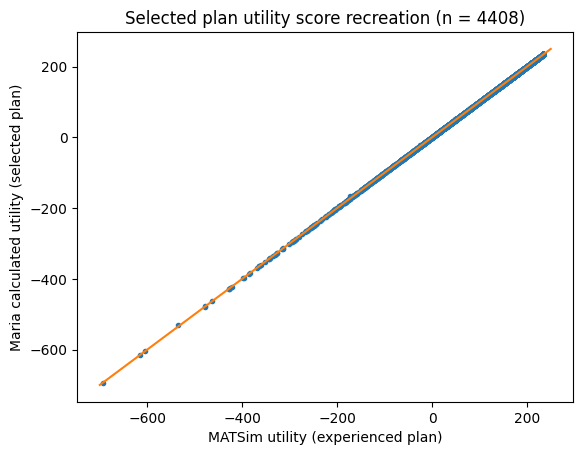

In [147]:
df2 = df[df["stuck_bool"]==0]
df3 = df[df["stuck_bool"]==1]
df4 = df[df["diff"]>100]


plt.plot(df["selected plan utility"], df["calculated_total_u"], ".", alpha=1)
# plt.plot(df2["selected plan utility"], df2["calculated_total_u"], ".")
# plt.plot(df3["selected plan utility"], df3["calculated_total_u"], ".")
# plt.legend(["not stuck", "stuck"])

x = [-700,50, 100, 250]
# y1 = [i*1.1 for i in x ]
# y2 = [i*0.9 for i in x ]
# y3 = [i+90 for i in x ]
plt.plot(x, x)
# plt.plot(x, y3)
plt.xlabel("MATSim utility (experienced plan)")
plt.ylabel("Maria calculated utility (selected plan)")
plt.title(f"Selected plan utility score recreation (n = {len(df)})")
# plt.plot(x, y1)
# plt.plot(x, y2)
# plt.plot(x, y3)
# plt.xlim(0,200)
# plt.ylim(0,200)

In [148]:
df["diff_abs"] = abs(df["diff"])
print(f"The number of agents with 1 util is {len(df[df["diff_abs"]<1])} which is {len(df[df["diff_abs"]<1])/len(df) * 100}%.")

The number of agents with 1 util is 4399 which is 99.79582577132487%.


In [ ]:
df.iloc[0]["selected plan boardingTime"]

### Calculate |x| and flex

### Ignore below: this is debugging errors

In [149]:
df[df["calculated_total_u"]<-600]

,id,subpopulation,planned plan activity_type_or_mode,planned plan duration,planned plan utility,selected plan activity_type_or_mode,selected plan distance_travelled,selected plan duration,selected plan location,selected plan routes,...,calculated_travel_u,tollvalue,tollcount,transfercount,calculated_penalty_u,total_travel_u,total_activity_u,calculated_total_u,diff,diff_abs
967,91323,medium,home; car; shop; car; home; car; shop; car; ho...,09:37:09; 00:06:18; 10:33:04; 00:05:31; 10:55:...,-604.943193,"[home, car, shop, car, home, car, shop, car, h...","[N/A, 5039.519020813916, N/A, 4561.45587791879...","[09:37:09, 02:23:38, 12:00:48, 01:40:03, 13:40...","[555256.0,178476.0, N/A, 557740.0,178974.0, N/...","[N/A, 136237 185627 487159 621549 517708166177...",...,"[-6.007903804162783, -5.91229117558376, -10.48...",60.0,2,0,-252.0,-124.090650,-228.829890,-604.920541,-0.022652,0.022652
1082,103460,medium,home; car; work; car; home; car; medical; car;...,07:14:01; 00:16:54; 09:40:25; 00:25:08; 11:08:...,-616.141145,"[home, car, work, car, home, car, medical, car...","[N/A, 20173.174192869807, N/A, 26425.897492407...","[07:14:01, 03:38:48, 10:52:50, 05:59:22, 16:52...","[572377.0,209512.0, N/A, 559660.0,221352.0, N/...","[N/A, 173328 5177144271265548177_5177144271300...",...,"[-9.034634838573961, -10.285179498481448, -6.2...",0.0,0,0,-252.0,-41.779126,-322.346918,-616.126044,-0.015102,0.015102
1184,114990,low,visit; walk; home; car; escort_work; car; home...,01:21:17; 00:00:00; 13:41:42; 00:07:27; 13:28:...,-694.352535,"[visit, walk, home, car, escort_work, car, hom...","[N/A, 0.0, N/A, 6881.107136704811, N/A, 8744.4...","[01:21:17, 00:00:01, 13:41:42, 01:10:29, 14:52...","[539941.0,191947.0, N/A, 539941.0,191947.0, N/...","[N/A, N/A, N/A, 5177064481273655185_5177064491...",...,"[0.0, -7.752442854681925, -8.497783935005806, ...",100.0,2,0,0.0,-285.743905,-408.601079,-694.344984,-0.007551,0.007551


In [150]:
print(f"id: {df.iloc[1545]["id"]}")
print(f"plan: {df.iloc[1545]["selected plan activity_type_or_mode"]}")
print(f"dur: {df.iloc[1545]["selected plan duration"]}")
print(f"ex plan: {df.iloc[1545]["experienced plan activity_type_or_mode"]}")
print(f"ex dur: {df.iloc[1545]["experienced plan duration"]}")
print(f"u: {df.iloc[1545]["selected plan utility"]}")
print(f"my u: {df.iloc[1545]["calculated_total_u"]}")
print(f"diff: {df.iloc[1545]["diff"]}")
print(f"travel us: {df.iloc[1545]["calculated_travel_u"]}")
print(f"activity us: {df.iloc[1545]["calculated_activity_u"]}")
print(f"penalty us: {df.iloc[1545]["calculated_penalty_u"]}")
print(f"stuck id: {df.iloc[1545]["stuck_index"]}")
print(f"stuck bool: {df.iloc[1545]["stuck_bool"]}")

id: 152301
plan: ['home', 'walk', 'education', 'walk', 'home']
dur: ['08:06:27', '00:21:22', '15:55:14', '00:21:22', 'N/A']


KeyError: 'experienced plan activity_type_or_mode'

In [ ]:
#this one for stucks
diffs = list(df["diff"])
calcutils = list(df["calculated_total_u"])
j=0
k=0
l=0
for i in range(len(diffs)):
    if (diffs[i])>5 :
    # if calcutils[i] < -600:
        print("i: "+str(i))
        print("id: "+str(df.iloc[i]["id"]))
        # print(df.iloc[i]["subpopulation"])
        print("diff: "+str(df.iloc[i]["diff"]))
        print(df.iloc[i]["selected plan activity_type_or_mode"])
        print(df.iloc[i]["experienced plan activity_type_or_mode"])
        print(f"stuck id: {df.iloc[i]["stuck_index"]}")
        print(f"stuck bool: {df.iloc[i]["stuck_bool"]}")
        print(f"activities: {df.iloc[i]["calculated_activity_u"]}")
        # print(df.iloc[i]["activity_starts"])
        # if df.iloc[i]["activity_starts"][-1]>86400:
        #     print("STARTS AFTER MIDNIGHT")
        #     k+=1
        # if df.iloc[i]["selected plan activity_type_or_mode"][0]==df.iloc[i]["selected plan activity_type_or_mode"][-1]:
        #     print("WRAP")
        #     print(df.iloc[i]["selected plan duration"])
        #     l+=1
        print(f"trips: {df.iloc[i]["calculated_travel_u"]}")
        print(f"real u: {df.iloc[i]["selected plan utility"]}")
        print(f"my u : {df.iloc[i]["calculated_total_u"]}")
        print(f"penalty : {df.iloc[i]["calculated_penalty_u"]}")
        print("_____________________________")
        j+=1
print(f"j: {j}")
print(f"k: {k}")
print(f"l: {l}")

i: 78
id: 8472
diff: 154.82265520201616
['home', 'car', 'escort_other', 'car', 'home', 'car', 'escort_other', 'car', 'home']
home; car; escort_other
stuck id: 10
stuck bool: 1
activities: [np.float64(156.77729042077408), np.float64(-0.8257825504765026), np.float64(-67.87896972704227), np.float64(-0.8257825504765026), np.float64(-58.68966699027934)]
trips: [np.float64(-9.501682339235536), np.float64(-9.443355380429653), np.float64(-9.303440589934713), np.float64(-8.681439963853665)]
real u: -105.55017446893795
my u : -260.3728296709541
penalty : -252.0
_____________________________
i: 531
id: 49062
diff: 149.45260615194422
['business', 'car', 'business', 'car', 'home', 'car', 'escort_other', 'car', 'home', 'walk', 'walk', 'bus', 'walk', 'rail', 'walk', 'rail', 'walk', 'taxi', 'escort_work', 'car', 'walk', 'walk', 'bus', 'walk', 'bus', 'walk', 'bus', 'walk', 'home', 'car', 'other', 'car', 'home']
business; car; business; car; home; car; escort_other; car; home; walk; pt interaction; walk

In [ ]:
#this one for non stucks
diffs = list(df["diff"])
calcutils = list(df["calculated_total_u"])
j=0
k=0
l=0
for i in range(len(diffs)):
    if abs(diffs[i])>5 :
    # if calcutils[i] < -600:
        print("i: "+str(i))
        print("id: "+str(df.iloc[i]["id"]))
        # print(df.iloc[i]["subpopulation"])
        print("diff: "+str(df.iloc[i]["diff"]))
        print("selected activities and duration:")
        print(df.iloc[i]["selected plan activity_type_or_mode"])
        print(df.iloc[i]["selected plan duration"])
        print("experienced activities and duration:")
        print(df.iloc[i]["experienced plan activity_type_or_mode"])
        print(df.iloc[i]["experienced plan duration"])
        print(f"stuck id: {df.iloc[i]["stuck_index"]}")
        print(f"activities: {df.iloc[i]["calculated_activity_u"]}")
        # print(df.iloc[i]["activity_starts"])
        # if df.iloc[i]["activity_starts"][-1]>86400:
        #     print("STARTS AFTER MIDNIGHT")
        #     k+=1
        # if df.iloc[i]["selected plan activity_type_or_mode"][0]==df.iloc[i]["selected plan activity_type_or_mode"][-1]:
        #     print("WRAP")
        #     print(df.iloc[i]["selected plan duration"])
        #     l+=1
        print(f"trips: {df.iloc[i]["calculated_travel_u"]}")
        print("_____________________________")
        j+=1
print(f"j: {j}")
print(f"k: {k}")
print(f"l: {l}")

i: 1
id: 56
diff: -58.22330883926708
selected activities and duration:
['home', 'car', 'work', 'car', 'home']
['04:52:47', '00:23:25', '17:49:04', '00:24:28', '24:05:47']
experienced activities and duration:
home; car; work; car; home
04:52:47; 00:26:49; 17:49:04; 05:06:36; N/A
stuck id: 6
activities: [np.float64(106.33659589551496), np.float64(106.55696646061497)]
trips: [np.float64(-9.345893166449294), np.float64(-9.139997238572171)]
_____________________________
i: 2
id: 223
diff: -16.554225850663897
selected activities and duration:
['home', 'walk', 'home', 'car', 'business']
['07:05:01', '00:00:00', '17:38:34', '01:38:56', '24:09:47']
experienced activities and duration:
home; walk; home; car; business
07:05:01; 00:00:01; 17:38:34; 07:32:36; N/A
stuck id: 6
activities: [np.float64(65.51987286256299), np.float64(105.44092680287709), np.float64(6.551595137082704)]
trips: [np.float64(0.0), np.float64(-33.527945313097575)]
_____________________________
i: 5
id: 519
diff: -53.900625580

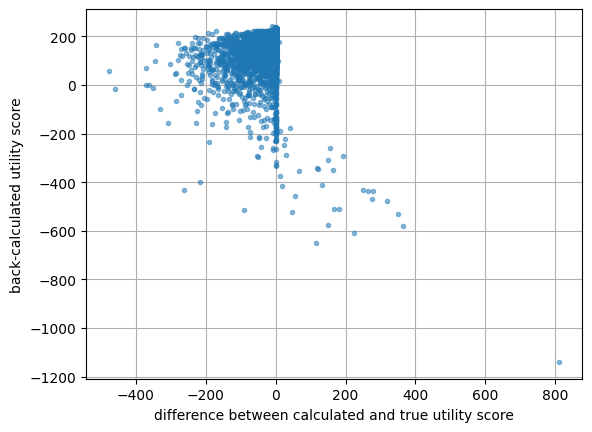

In [ ]:
plt.plot(df["diff"], df["calculated_total_u"], ".", alpha=0.5)
plt.ylabel("back-calculated utility score")
plt.xlabel("difference between calculated and true utility score")
# plt.xlim([-5,5])
plt.grid()

In [ ]:
def list_of_modes(activity_type_or_mode, activity_indices):
    legs = [val for i, val in enumerate(activity_type_or_mode) if i not in activity_indices]
    return legs

def check_for_modes(modes, target):
    all_tareget_bool = int(all(item == target for item in modes))
    return all_tareget_bool

def check_for_modes_list(modes, target_list):
    all_tareget_bool = int(all(item in target_list for item in modes))
    return all_tareget_bool

def check_for_any_pt_modes(modes, target_list):
    all_tareget_bool = int(any(item in target_list for item in modes) and "car" not in modes)
    return all_tareget_bool

In [ ]:
df["db_trips"] = df.apply(lambda row: list_of_modes(row["selected plan activity_type_or_mode"], row["activities_indices"]), axis=1)

In [ ]:
df["all_car"] = df.apply(lambda row: check_for_modes(row["db_trips"], "car"), axis=1)
df["all_walk"] = df.apply(lambda row: check_for_modes_list(row["db_trips"], "walk"), axis=1)
df["pt_some"] = df.apply(lambda row: check_for_any_pt_modes(row["db_trips"], ["bus", "rail", "subway", "ferry", "tram"]), axis=1)

In [ ]:
df["db_trips_unique"] = df['db_trips'].apply(lambda x: list(set(x)) if isinstance(x, list) else x)

In [ ]:
df["bus_count"] = df["db_trips_unique"].apply(lambda x: x.count("bus") if isinstance(x, list) else 0)
df["car_count"] = df["db_trips_unique"].apply(lambda x: x.count("car") if isinstance(x, list) else 0)
df["rail_count"] = df["db_trips_unique"].apply(lambda x: x.count("rail") if isinstance(x, list) else 0)
df["subway_count"] = df["db_trips_unique"].apply(lambda x: x.count("subway") if isinstance(x, list) else 0)
df["walk_count"] = df["db_trips_unique"].apply(lambda x: x.count("walk") if isinstance(x, list) else 0)

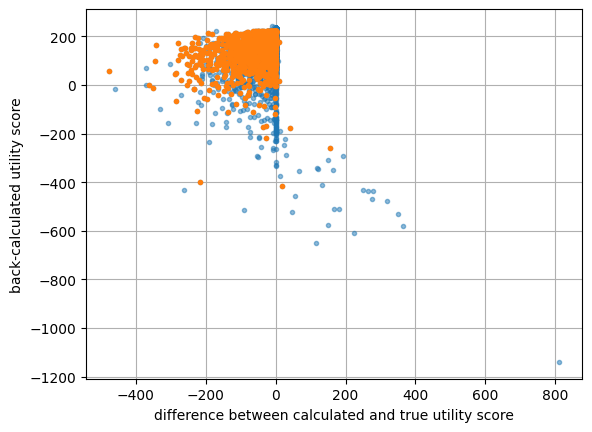

In [ ]:
df_car = df[df["all_car"]==1]
df_walk = df[df["all_walk"]==1]
df_pt = df[df["pt_some"]==1]

dfc1 = df_car[df_car["tollcount"]==0]
dfc2 = df_car[df_car["tollcount"]>0]

dfpt1 = df_pt[df_pt["transfercount"]>0]
dfpt2 = df_pt[df_pt["diff"]>5]

plt.plot(df["diff"], df["calculated_total_u"], ".", alpha=0.5)
plt.plot(df_car["diff"], df_car["calculated_total_u"], ".", alpha=1)
# plt.plot(dfc2["diff"], dfc2["calculated_total_u"], ".", alpha=1)
# plt.plot(df_walk["diff"], df_walk["calculated_total_u"], ".", alpha=0.5)
# plt.plot(df_pt["diff"], df_pt["calculated_total_u"], ".", alpha=1)
# plt.plot(dfpt1["diff"], dfpt1["calculated_total_u"], ".", alpha=1)
# plt.xlim(-5,20)
plt.ylabel("back-calculated utility score")
plt.xlabel("difference between calculated and true utility score")
# plt.xlim([0,40])
plt.grid()